# Project 1 - Information Retrieval as a recommender system

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Pre-processing

### Load datas

In [4]:
reviews = pd.read_csv('data/reviews83325.csv')
reviews.head()

/var/folders/jc/0rdgc11d06dgm3sng453_7yr0000gn/T/ipykernel_3205/3645581194.py:1: DtypeWarning: Columns (15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.read_csv('data/reviews83325.csv')


,id,idplace,titre,idauteur,review,note,date_review,date_visit,langue,published_platform,...,subratings,machine_translated,machine_translatable,owner_id,owner_langue,owner_date_review,owner_connection,owner_responder,owner_response,owner_title
0,771569620,188467,February,F645CC9429E8A40EB1F5A487780EC683,Personally I think it is the most beautiful sq...,5,23/9/2020 11:14:11,2020-02,en,Desktop,...,[],False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,769814072,188467,Nice green square,AFFB511F21DF819776CB2F8013034382,We walked through this lovely park but did not...,4,11/9/2020 07:52:32,2019-10,en,Desktop,...,[],False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,758953508,188467,A Treasure in Paris,9262311F3378F8CC4709DD4D92380278,We come back to this huge square every time we...,5,5/7/2020 03:16:32,2019-10,en,Desktop,...,[],False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,755705747,188467,A place to take a breath from exploring Paris.,836BAA8786B81033412B950CF5BDA70C,The most beautiful square in Paris has a stran...,5,31/5/2020 19:36:17,2019-06,en,Desktop,...,[],False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,750396525,188467,Beautiful and elegant,8FEC7B1C9034428EFF3BF8728B036829,"Lovely architecture, looks different again to ...",4,11/3/2020 06:16:38,2020-03,en,Desktop,...,[],False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
reviews.shape

(340385, 21)

In [6]:
tripadvisor = pd.read_csv('data/Tripadvisor.csv')
tripadvisor.head()
tripadvisor.columns

Index(['id', 'idTrip', 'fromId', 'nom', 'url', 'rating', 'nbAvis',
       'nbAvisRecupere', 'latitude', 'longitude', 'typeR', 'adresse',
       'priceRange', 'closed', 'hotelType', 'hotelStyle', 'hotelStars',
       'hotelRoomNumber', 'hotelNoteEmplacement', 'hotelNoteProprete',
       'hotelNoteService', 'HotelNoteQualitePrix', 'hoteldistance',
       'hotelbearing', 'restaurantTypeCuisine',
       'restaurantDietaryRestrictions', 'restaurantMeals',
       'restaurantFeatures', 'restaurantNoteCuisine', 'restaurantNoteService',
       'restaurantNoteQualitePrix', 'restaurantNoteAmbiance', 'activiteType',
       'activiteSubCategorie', 'activiteSubType', 'website', 'nbScanReview',
       'dateLastScanReviews', 'shape_gid', 'gadm36_gid', 'hotelprice',
       'hotelBookingID', 'restaurantSubcategory', 'restaurantType',
       'ap_additional_info', 'ap_age_band_list', 'ap_attraction_ids',
       'ap_booking_question_list', 'ap_bubble_rating_integer', 'ap_duration',
       'ap_exclusion', '

We can see that the _id_ column in this dataset corresponds to the _idplace_ column in the **reviews** dataset. Therefore, the **reviews** dataset is simply the extended version, with all the reviews relating to the lines in the **tripadvisor** dataset.

In [7]:
tripadvisor.shape

(3761, 60)

#### Keep only english reviews
In order to apply the data to a model, it is necessary to use a specific language to simplify matters. We use English because the majority of journals are in this language.

In [8]:
reviews = reviews[reviews.langue == 'en']
reviews.shape

(153071, 21)

#### Keep usefull features
Here for our project we just need to focus on reviews and the place, so we only keep the review and the idplace.

In [9]:
reviews = reviews[['idplace', 'review']]
reviews.head()

,idplace,review
0,188467,Personally I think it is the most beautiful sq...
1,188467,We walked through this lovely park but did not...
2,188467,We come back to this huge square every time we...
3,188467,The most beautiful square in Paris has a stran...
4,188467,"Lovely architecture, looks different again to ..."


In [10]:
tripadvisor = tripadvisor[['id','nom', 'rating','activiteSubType','activiteSubCategorie','restaurantTypeCuisine','restaurantDietaryRestrictions']]
tripadvisor.head()

,id,nom,rating,activiteSubType,activiteSubCategorie,restaurantTypeCuisine,restaurantDietaryRestrictions
0,188467,Place des Vosges,4.108407,163,47,NaN,NaN
1,188468,Rue des Francs Bourgeois,3.316532,163,47,NaN,NaN
2,188470,Village Saint-Paul,3.017118,"34,144","26,47,51",NaN,NaN
3,188471,Au Passe-partout,2.743157,137,26,NaN,NaN
4,188472,Cloître des Billettes,2.942987,10,47,NaN,NaN


In [11]:
tripadvisor.dtypes

id                                 int64
nom                               object
rating                           float64
activiteSubType                   object
activiteSubCategorie              object
restaurantTypeCuisine             object
restaurantDietaryRestrictions     object
dtype: object

We can see that the type columns do not have the correct format; we need to accept a list of integers containing the ID values.

In [12]:
tripadvisor['activiteSubType'] = tripadvisor['activiteSubType'].apply(
    lambda s: [int(x.strip()) for x in str(s).split(",") if x is not np.nan and x != 'nan']
)
tripadvisor['activiteSubCategorie'] = tripadvisor['activiteSubCategorie'].apply(
    lambda s: [int(x.strip()) for x in str(s).split(",") if x is not np.nan and x != 'nan']
)
tripadvisor['restaurantTypeCuisine'] = tripadvisor['restaurantTypeCuisine'].apply(
    lambda s: [int(x.strip()) for x in str(s).split(",") if x is not np.nan and x != 'nan']
)
tripadvisor['restaurantDietaryRestrictions'] = tripadvisor['restaurantDietaryRestrictions'].apply(
    lambda s: [int(x.strip()) for x in str(s).split(",") if x is not np.nan and x != 'nan']
)
tripadvisor.head()


,id,nom,rating,activiteSubType,activiteSubCategorie,restaurantTypeCuisine,restaurantDietaryRestrictions
0,188467,Place des Vosges,4.108407,[163],[47],[],[]
1,188468,Rue des Francs Bourgeois,3.316532,[163],[47],[],[]
2,188470,Village Saint-Paul,3.017118,"[34, 144]","[26, 47, 51]",[],[]
3,188471,Au Passe-partout,2.743157,[137],[26],[],[]
4,188472,Cloître des Billettes,2.942987,[10],[47],[],[]


### Load place dataset

In [13]:
attractionSubCat = pd.read_csv('data/AttractionSubCategorie.csv')
attractionSubType = pd.read_csv('data/AttractionSubType.csv')
cuisine = pd.read_csv('data/cuisine.csv')
dietaryRestrictions = pd.read_csv('data/dietary_restrictions.csv')

In [14]:
print(attractionSubCat.shape, attractionSubCat.head(),"\n")
print(attractionSubType.shape, attractionSubType.head(), "\n")
print(cuisine.shape, cuisine.head(), "\n")
print(dietaryRestrictions.shape, dietaryRestrictions.head(), "\n")

(20, 2)    id               name
0  20       Vie nocturne
1  26           Shopping
2  36       Restauration
3  40  Spas et bien-être
4  41  Cours et ateliers 

(229, 2)    id                      name
0   1            Galeries d'art
1   2          Ruines anciennes
2   3  Bâtiments architecturaux
3   4        Champs de bataille
4   5                     Ponts 

(161, 2)      id      name
0  4617   Italian
1  5086    French
2  5110   Mexican
3  5379   Chinese
4  5473  Japanese 

(5, 2)       id                 name
0  10665  Vegetarian Friendly
1  10697        Vegan Options
2  10751                Halal
3  10768               Kosher
4  10992  Gluten Free Options 



#### We will add a standard column to indicate the file name, e.g. AttractionSubCategory, and then be able to merge all these dataframes

In [15]:
attractionSubCat['type'] = 'AttractionSubCategorie'
attractionSubType['type'] = 'AttractionSubType'
cuisine['type'] = 'Cuisine'
dietaryRestrictions['type'] = 'DietaryRestriction'

col = ["type", "id", "name"]
infos_places = pd.concat(
    [attractionSubCat[col],
     attractionSubType[col],
     cuisine[col],
     dietaryRestrictions[col]],
    ignore_index=True
)

# Save it to a new CSV file
infos_places.to_csv("data/infos_places.csv", index=False)

print(infos_places.shape)
infos_places.head()

(415, 3)


,type,id,name
0,AttractionSubCategorie,20,Vie nocturne
1,AttractionSubCategorie,26,Shopping
2,AttractionSubCategorie,36,Restauration
3,AttractionSubCategorie,40,Spas et bien-être
4,AttractionSubCategorie,41,Cours et ateliers


## Basic text cleaning
1. Convert reviews to lowercase

In [16]:
reviews['review'] = reviews['review'].apply(lambda x: x.lower())
reviews.head()

,idplace,review
0,188467,personally i think it is the most beautiful sq...
1,188467,we walked through this lovely park but did not...
2,188467,we come back to this huge square every time we...
3,188467,the most beautiful square in paris has a stran...
4,188467,"lovely architecture, looks different again to ..."


2. Remove punctuation and numbers if necessary

In [17]:
reviews['review'].iloc[0]

'personally i think it is the most beautiful square of paris. well maintained and the area around it gives you opportunities to grab a bite to eat as well.'

In [18]:
#!pip3 install nltk
import ssl

# Permet de contourner les problèmes de certificat SSL lors du téléchargement des ressources NLTK
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    # Environnements qui n'ont pas cette méthode (vieux Python)
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

import nltk
nltk.download('punkt_tab') # tokenizers
nltk.download('stopwords') # listes de stopwords
nltk.download('wordnet')  # WordNet pour la lemmatisation
import string
from nltk.tokenize import TreebankWordTokenizer

[nltk_data] Downloading package punkt_tab to /Users/marya/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/marya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/marya/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
wordTokenizer = TreebankWordTokenizer()
reviews['review'] = reviews['review'].apply(lambda x: [mot for mot in wordTokenizer.tokenize(x) if mot not in string.punctuation])
reviews['review'].iloc[0]

['personally',
 'i',
 'think',
 'it',
 'is',
 'the',
 'most',
 'beautiful',
 'square',
 'of',
 'paris.',
 'well',
 'maintained',
 'and',
 'the',
 'area',
 'around',
 'it',
 'gives',
 'you',
 'opportunities',
 'to',
 'grab',
 'a',
 'bite',
 'to',
 'eat',
 'as',
 'well']

3. Remove stopwords

In [20]:
from nltk.corpus import stopwords

stop = stopwords.words('english')

reviews['review'] = reviews['review'].apply(lambda x: [mot for mot in x if mot not in stop])
reviews['review'].iloc[0]

['personally',
 'think',
 'beautiful',
 'square',
 'paris.',
 'well',
 'maintained',
 'area',
 'around',
 'gives',
 'opportunities',
 'grab',
 'bite',
 'eat',
 'well']

4. Lemmatisation

In [21]:
from nltk.stem import WordNetLemmatizer

lemmatizer_output = WordNetLemmatizer()

reviews['review'] = reviews['review'].apply(lambda x: [lemmatizer_output.lemmatize(mot) for mot in x])
reviews['review'].iloc[0]

['personally',
 'think',
 'beautiful',
 'square',
 'paris.',
 'well',
 'maintained',
 'area',
 'around',
 'give',
 'opportunity',
 'grab',
 'bite',
 'eat',
 'well']

**Comments** We don't see much change because the words are already in their lemmatised form, but we can see that some words are in the singular, such as give and opportunity.

## Reduction in the number of reviews per location

1. Group by idplace & for each one, calculate the length of each review (total token)

In [22]:
# group by idplace and concatenate the reviews
reviews = reviews.groupby('idplace').agg({'review': 'sum'})
reviews.head()

,review
idplace,
188467,"[personally, think, beautiful, square, paris.,..."
188468,"[old, college, friend, booked, beautiful, expe..."
188470,"[winter, lot, going, however, easy, see, cobbl..."
188471,"[call, au, passe, partout, shop, serious, unde..."
188472,"[old, historical, place., attended, experience..."


In [23]:
# sort by number of tokens
reviews['review_length'] = reviews['review'].apply(lambda x: len(x))
reviews.head()

,review,review_length
idplace,,
188467,"[personally, think, beautiful, square, paris.,...",56902
188468,"[old, college, friend, booked, beautiful, expe...",694
188470,"[winter, lot, going, however, easy, see, cobbl...",2048
188471,"[call, au, passe, partout, shop, serious, unde...",54
188472,"[old, historical, place., attended, experience...",113


2. Retain as many of the most frequent N tokens per review

In [24]:
from collections import Counter

# by default K is the mean of the review lengths to keep a similar number of words in each review
K = int(reviews["review_length"].mean())

# sort the tokens by frequency and keep only the top K tokens
def top_k_tokens(tokens, k=None):
    if k is None:
        k = len(tokens)
    k = int(k)

    c = Counter(tokens)
    return [mot for mot, freq in c.most_common(k)]

reviews["top_tokens"] = reviews["review"].apply(
    lambda toks: top_k_tokens(toks, k=K)
)

reviews.head()



,review,review_length,top_tokens
idplace,,,
188467,"[personally, think, beautiful, square, paris.,...",56902,"[place, square, de, park, paris, beautiful, 's..."
188468,"[old, college, friend, booked, beautiful, expe...",694,"[street, one, apartment, shopping, lot, area, ..."
188470,"[winter, lot, going, however, easy, see, cobbl...",2048,"[shop, place, one, village, little, antique, a..."
188471,"[call, au, passe, partout, shop, serious, unde...",54,"[history, n't, owner, unique, call, au, passe,..."
188472,"[old, historical, place., attended, experience...",113,"[de, art, place, church, paris., billettes, cl..."


3. Create text_resume ready for TF‑IDF and create a ready-to-use dataframe

In [25]:
reviews["text_resume"] = reviews["top_tokens"].apply(lambda toks: " ".join(toks))
reviews.head()

,review,review_length,top_tokens,text_resume
idplace,,,,
188467,"[personally, think, beautiful, square, paris.,...",56902,"[place, square, de, park, paris, beautiful, 's...",place square de park paris beautiful 's one vo...
188468,"[old, college, friend, booked, beautiful, expe...",694,"[street, one, apartment, shopping, lot, area, ...",street one apartment shopping lot area marais ...
188470,"[winter, lot, going, however, easy, see, cobbl...",2048,"[shop, place, one, village, little, antique, a...",shop place one village little antique area pau...
188471,"[call, au, passe, partout, shop, serious, unde...",54,"[history, n't, owner, unique, call, au, passe,...",history n't owner unique call au passe partout...
188472,"[old, historical, place., attended, experience...",113,"[de, art, place, church, paris., billettes, cl...",de art place church paris. billettes cloister ...


In [26]:
reviews_for_tfidf = reviews[['text_resume']]
reviews_for_tfidf = reviews_for_tfidf.reset_index()

# save the preprocessed reviews to a new CSV file
reviews_for_tfidf.to_csv("data/preprocessed_reviews.csv", index=True)
reviews_for_tfidf.head()

,idplace,text_resume
0,188467,place square de park paris beautiful 's one vo...
1,188468,street one apartment shopping lot area marais ...
2,188470,shop place one village little antique area pau...
3,188471,history n't owner unique call au passe partout...
4,188472,de art place church paris. billettes cloister ...


## Vector Representation of Places with TF-IDF

After cleaning the reviews (lowercasing, removing stopwords, lemmatizing, etc.), each place ends up with one clean text that combines all of its reviews.
The goal at this stage is to turn this text into something numerical so we can compare places.

To do that, we use TF‑IDF. It highlights the words that really matter in the reviews while reducing the weight of very common terms.
In the end, every place is represented as a numerical vector, which makes it easy to measure how similar two places are based on what people wrote about them..

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# We use the cleaned text from the previous preprocessing steps
vectorizer = TfidfVectorizer()

# Convert each place's aggregated review text into a TF‑IDF vector
tfidf_matrix = vectorizer.fit_transform(reviews_for_tfidf["text_resume"])

# Check the shape: (number of places, number of unique words)
tfidf_matrix.shape

(1835, 50322)

We use TF‑IDF as a baseline representation for textual similarity. It helps us highlight the terms that matter most in each place description while reducing the impact of words that appear too frequently across all locations.

The number of reviews per place varies a lot, which can lead to differences in document length. TF‑IDF normalization reduces this imbalance, but longer documents may still contain a richer vocabulary simply because more text is available.

## Cosinus similarity 
In order to recommend a similar place, we need to measure the closeness between TF-IDF vectors. We use cosine similarity, which measures the angle between two vectors. The closer the value is to 1, the more similar the places are.

In [28]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute the cosine similarity between all TF-IDF vectors
similarity_matrix = cosine_similarity(tfidf_matrix)

# Check the size of the similarity matrix
similarity_matrix.shape

(1835, 1835)

#### Recommendation system

We now implement a simple content-based recommendation function. Given a place ID, the system retrieves the most similar place based on cosinus similarity. No metadata (such as categories, cuisine type, or ratings) is used when generating recommendations.

In [29]:
def recommend_place(place_id, reviews_df, similarity_matrix):
    
    # Find the index of the selected place in the dataframe
    idx = reviews_df[reviews_df["idplace"] == place_id].index[0]
    
    # Get similarity scores between this place and all others
    sim_scores = list(enumerate(similarity_matrix[idx]))
    
    # Sort places by similarity (highest first)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # The first item is the place itself => take the second most similar place
    best_match_index = sim_scores[1][0]
    
    return reviews_df.iloc[best_match_index]["idplace"]

##### Testing the Recommendation Function

In [30]:
# Select a place ID to test the recommendation system
test_place = reviews_for_tfidf["idplace"].iloc[0]

# Get the most similar place based on the similarity matrix
recommended = recommend_place(test_place, reviews_for_tfidf, similarity_matrix)

# Display the result
print("Starting point :", test_place)
print("Recommended place :", recommended)

Starting point : 188467
Recommended place : 292257


In [31]:
def get_place_name(place_id):
    # Look up the place name in the Tripadvisor dataframe using its ID
    return tripadvisor[tripadvisor["id"] == place_id]["nom"].values[0]

# Print the names of the starting place and the recommended place
print("Starting point :", get_place_name(test_place))
print("Recommended place :", get_place_name(recommended))

Starting point : Place des Vosges
Recommended place : Le Marais 


**Interpretation**

The recommendation is coherent from a textual perspective. "Place des Vosges" and "Le Marais" share strong thematic overlap in their reviews, particularly regarding architecture, historical heritage, walking experience, and atmosphere.

This result supports the hypothesis of the project: places that are described with similar words tend to be similar. The recommendation is based solely on textual similarity, without using any metadata such as category or location.

## Function to Recommend the Top‑K Similar Places

In [32]:
def recommend_top_k(place_id, reviews_df, similarity_matrix, k=5):
    
    # Find the index of the selected place in the dataframe
    idx = reviews_df[reviews_df["idplace"] == place_id].index[0]
    
    # Get similarity scores between this place and all others
    sim_scores = list(enumerate(similarity_matrix[idx]))
    
    # Sort all places by similarity (highest first)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Skip the first one (it is the same place) and take the top-k similar ones
    sim_scores = sim_scores[1:k+1]
    
    # Extract the corresponding place IDs
    recommended_ids = [reviews_df.iloc[i[0]]["idplace"] for i in sim_scores]
    
    return recommended_ids

In [33]:
top5 = recommend_top_k(test_place, reviews_for_tfidf, similarity_matrix, k=5)

print("Starting point:", get_place_name(test_place))
print("Top 5 :")

for pid in top5:
    print( get_place_name(pid))

Starting point: Place des Vosges
Top 5 :
Le Marais 
Île Saint-Louis
Cathédrale Notre-Dame de Paris
Le Pavillon de la Reine
Tours de la Cathedrale Notre-Dame


**Analysis of the Top-5 recommendations**

The Top-5 recommendations are all located in the same geographical and historical area of Paris.

Most of them are historical landmarks or culturally significant places. 
This suggests that the model captures not only lexical similarity but also thematic proximity related to heritage, architecture, and tourism.

The clustering of recommendations around the same area indicates that the textual representation successfully encodes contextual information present in the reviews.

## Preprocessing Metadata for Evaluation 

In [34]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load the full Tripadvisor dataset
meta_full = pd.read_csv('data/Tripadvisor.csv', low_memory=False)

# Keep only the columns needed for evaluation
meta = meta_full[['id', 'typeR', 'activiteSubCategorie', 'restaurantType', 'priceRange']].copy()

# Convert activiteSubCategorie into a list of integers
meta['activiteSubCategorie'] = meta['activiteSubCategorie'].apply(
    lambda s: [int(x.strip()) for x in str(s).split(',') if x.strip() not in ['nan', '']]
)

# Convert restaurantType into a list of integers
meta['restaurantType'] = meta['restaurantType'].apply(
    lambda s: [int(x.strip()) for x in str(s).split(',') if x.strip() not in ['nan', '']]
)

# Display metadata shape and show how many places we have by type (AP, R, A, H)
print(meta.shape)
print(meta['typeR'].value_counts())

meta.head(10)

(3761, 5)
typeR
AP    2669
R      623
A      405
H       64
Name: count, dtype: int64


,id,typeR,activiteSubCategorie,restaurantType,priceRange
0,188467,A,[47],[],NaN
1,188468,A,[47],[],NaN
2,188470,A,"[26, 47, 51]",[],NaN
3,188471,A,[26],[],NaN
4,188472,A,[47],[],NaN
5,188493,A,[26],[],NaN
6,188679,A,[47],[],NaN
7,188738,H,[],[],€€€€
8,188745,H,[],[],€€
9,188758,A,[49],[],NaN


**Interpretation**

The metadata dataframe has 3761 rows (places) and 5 columns which are id, typeR, activiteSubCategorie, restaurantType, priceRange.

We notice that there is a clear class imbalance, most places are of type AP:

- AP: 2,669 (71.0%)
- R: 623 (16.6%)
- A: 405 (10.8%)
- H: 64 (1.7%)


## Train/Test Split (50/50) and TF‑IDF Vectorization for Evaluation

We split places (not individual reviews) to simulate a realistic recommendation setup:

- Train = query set (places we search from)
- Test = candidate set (places we recommend from)
- Metadata is used only for evaluation, never as model input.

We also limit the vocabulary to 5,000 features to reduce dimensionality and speed up similarity ranking during evaluation.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1) Split places into train and test (50/50)
train_df, test_df = train_test_split(reviews_for_tfidf, test_size=0.5, random_state=42)

# 2) TF-IDF vectorization with a capped vocabulary for efficiency
tfidf_eval = TfidfVectorizer(max_features=5000, stop_words='english')
train_matrix = tfidf_eval.fit_transform(train_df['text_resume'].fillna(''))
test_matrix  = tfidf_eval.transform(test_df['text_resume'].fillna(''))

# 3) Compute cosine similarity between TRAIN (queries) and TEST (candidates)
sim_matrix = cosine_similarity(train_matrix, test_matrix)

print("Computation completed.")
print("Similarity matrix shape:", sim_matrix.shape)

Computation completed.
Similarity matrix shape: (917, 918)


## Ranking Error : Level 1 (typeR)

For each train place, rank all test places by cosine similarity (descending).
Record the position (0-indexed) of the first test place that shares the same typeR.

- Error = 0 => perfect (the very top match has the same type)
- Error = k => you need to go down to rank k to find the first same-type match
- No match of that type in test → ignore the query

In [36]:
# --- Level 1 Ranking Error (by typeR) ---

# Join minimal metadata (typeR) to the split sets
train_meta = train_df.merge(meta[['id', 'typeR']], left_on='idplace', right_on='id', how='left')
test_meta  = test_df.merge(meta[['id', 'typeR']], left_on='idplace', right_on='id', how='left')

# Array of test types aligned with the columns of sim_matrix
test_types = test_meta['typeR'].values

errors_l1 = []

for i in range(len(train_df)):
    # Type of the query (train) place
    query_type = train_meta.iloc[i]['typeR']

    # Skip if missing or if this type does not exist in test
    if pd.isna(query_type):
        continue
    if query_type not in test_types:
        continue

    # Ranked indices of test places by similarity to train[i] (highest first)
    ranked = sim_matrix[i].argsort()[::-1]

    # Find the first test place that matches the query type
    for rank, idx in enumerate(ranked):
        if test_types[idx] == query_type:
            errors_l1.append(rank)
            break

# Aggregate metrics
mean_l1 = sum(errors_l1) / len(errors_l1)
median_l1 = sorted(errors_l1)[len(errors_l1) // 2]

print(f"Nb requêtes évaluées  : {len(errors_l1)}")
print(f"Mean Ranking Error L1 : {mean_l1:.2f}")
print(f"Median Ranking Error  : {median_l1}")

Nb requêtes évaluées  : 917
Mean Ranking Error L1 : 0.59
Median Ranking Error  : 0


Most train places find a same-type match right at the top of the ranking, since the median error is 0. On average, the first same-type match appears around rank 0–1 (mean = 0.59), which is strong.

Part of this good result is likely due to class imbalance: Attraction Products (AP) make up a large share of the dataset, so it’s statistically easier to find another AP in the top positions. In short, the model benefits from both textual similarity and the prevalence of the majority class.

## Ranking Error : Level 2 (sub-catégories)

Evaluate ranking quality using fine‑grained categories that depend on the place type:

- Attractions (A / AP) => activiteSubCategorie (list of ints)
- Restaurants (R) => restaurantType (list of ints)
- Hotels (H) => priceRange (scalar like €€, €€€€)

Positive match rule: a recommended test place is considered a match if it shares at least one category with the query (for H, the price range must match).

In [37]:
# --- Level 2 Ranking Error (fine-grained categories) ---

# Join full metadata (we need the category fields)
train_meta2 = train_df.merge(meta, left_on='idplace', right_on='id', how='left')
test_meta2  = test_df.merge(meta, left_on='idplace', right_on='id', how='left')


def get_cats(row):
    """
    Return the fine-grained categories for a given place, depending on its type.
    - A/AP: activiteSubCategorie (list of ints)
    - R:    restaurantType (list of ints)
    - H:    priceRange (single scalar, turned into a one-element list)
    """
    t = row['typeR']
    if t in ('A', 'AP'):
        c = row['activiteSubCategorie']
        return c if isinstance(c, list) else []
    elif t == 'R':
        c = row['restaurantType']
        return c if isinstance(c, list) else []
    elif t == 'H':
        pr = row['priceRange']
        return [pr] if pd.notna(pr) else []
    return []


# Precompute categories for all test places (saves repeated work in the loop)
test_cats_list = [get_cats(test_meta2.iloc[j]) for j in range(len(test_df))]

errors_l2 = []

for i in range(len(train_df)):
    # Categories for the query (train) place
    query_cats = get_cats(train_meta2.iloc[i])

    # Skip if the query has no categories (cannot evaluate)
    if not query_cats:
        continue

    query_set = set(query_cats)

    # Skip if there is no possible match in the test set
    if not any(query_set & set(c) for c in test_cats_list):
        continue

    # Ranked indices of test places by similarity to train[i] (highest first)
    ranked = sim_matrix[i].argsort()[::-1]

    # Find the first recommended test place that shares at least one category
    for rank, idx in enumerate(ranked):
        if query_set & set(test_cats_list[idx]):
            errors_l2.append(rank)
            break

# Aggregate metrics
mean_l2 = sum(errors_l2) / len(errors_l2)
median_l2 = sorted(errors_l2)[len(errors_l2) // 2]

print(f"Nb requêtes évaluées  : {len(errors_l2)}")
print(f"Mean Ranking Error L2 : {mean_l2:.2f}")
print(f"Median Ranking Error  : {median_l2}")

Nb requêtes évaluées  : 414
Mean Ranking Error L2 : 3.35
Median Ranking Error  : 0


Level‑2 is tougher than Level‑1 because it checks for shared subcategories, which are more specific than general types. That’s why the average error is higher.

Even so, the median error is 0, meaning that for many places, the first recommended result already matches the correct subcategory. This shows that the model often captures the finer themes in the reviews.

Only 414 places were evaluated because some entries don’t have usable subcategories or don’t have any possible match in the test set. That’s expected.

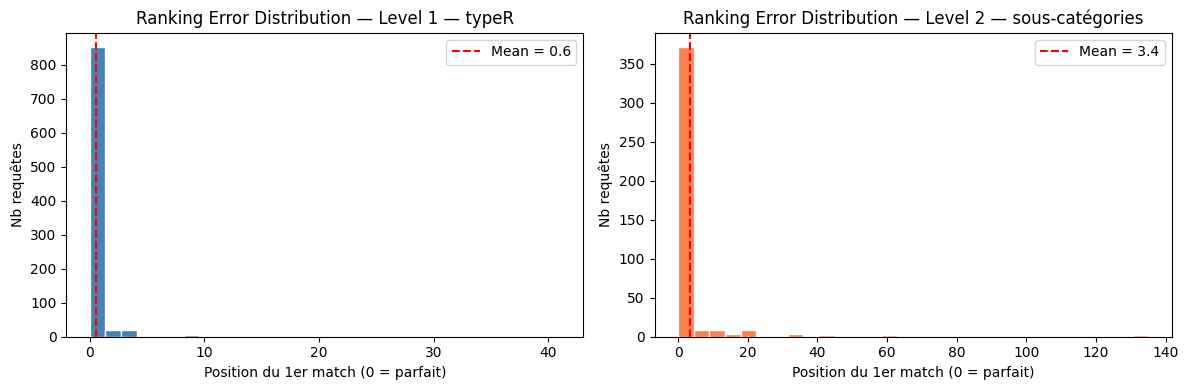


Résumé :
  Mean Ranking Error Level 1 : 0.59
  Mean Ranking Error Level 2 : 3.35


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, errors, title, color, mean_val in [
    (axes[0], errors_l1, 'Level 1 — typeR',           'steelblue', mean_l1),
    (axes[1], errors_l2, 'Level 2 — sous-catégories', 'coral',     mean_l2)
]:
    ax.hist(errors, bins=30, color=color, edgecolor='white')
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean = {mean_val:.1f}')
    ax.set_title(f'Ranking Error Distribution — {title}')
    ax.set_xlabel('Position du 1er match (0 = parfait)')
    ax.set_ylabel('Nb requêtes')
    ax.legend()

plt.tight_layout()
plt.savefig('ranking_error_distribution.png', dpi=150)
plt.show()

print(f"\Summary :")
print(f"  Mean Ranking Error Level 1 : {mean_l1:.2f}")
print(f"  Mean Ranking Error Level 2 : {mean_l2:.2f}")

**Interpretation**

- Level 1 (typeR): Errors are tightly concentrated at 0–1 with a mean around 0.59. In practice, this means the correct type is usually found at the very top of the ranking (rank 0) or very close to it.
- Level 2 (subcategories): Errors are more spread out, with a higher mean (3.36), which is expected because subcategory matching is stricter. Still, many queries hit rank 0, showing that the text-based representation often recovers the right fine-grained theme.

Lower is better. Level 1 is easier (coarse type), Level 2 is stricter (subcategory), so its average error is higher even though a good share of queries still get a perfect first match.

## Our model vs bm25
### Installation

In [39]:
#!pip3 install rank_bm25

### Initializing

In [43]:
from rank_bm25 import BM25Okapi
import pandas as pd

reviews = pd.read_csv("data/preprocessed_reviews.csv", index_col=0)
reviews.head()

,idplace,text_resume
0,188467,place square de park paris beautiful 's one vo...
1,188468,street one apartment shopping lot area marais ...
2,188470,shop place one village little antique area pau...
3,188471,history n't owner unique call au passe partout...
4,188472,de art place church paris. billettes cloister ...


In [44]:
train_df, test_df = train_test_split(reviews, test_size=0.5, random_state=42)

tokenized_test = [doc.split(" ") for doc in test_df["text_resume"]]

bm25 = BM25Okapi(tokenized_test)

### Ranking Error : Level 1 (typeR)

In [45]:
# build the BM25 score matrix
import numpy as np

bm25_scores = np.zeros((len(train_df), len(test_df)), dtype=float)

for i, doc in enumerate(train_df["text_resume"]):
    tokenized_query = doc.split(" ")
    bm25_scores[i, :] = bm25.get_scores(tokenized_query)
    
# Join minimal metadata (typeR) to the split sets
train_meta = train_df.merge(meta[["id", "typeR"]], left_on="idplace", right_on="id", how="left")
test_meta  = test_df.merge(meta[["id", "typeR"]], left_on="idplace", right_on="id", how="left")
test_types = test_meta["typeR"].values

In [ ]:
errors_l1_bm25 = []


for i in range(len(train_df)):
    query_type = train_meta.iloc[i]["typeR"]

    if pd.isna(query_type):
        continue
    if query_type not in test_types:
        continue

    # descending order of BM25 scores
    ranked = bm25_scores[i].argsort()[::-1]

    for rank, idx in enumerate(ranked):
        if test_types[idx] == query_type:
            errors_l1_bm25.append(rank)
            break

mean_l1_bm25 = sum(errors_l1_bm25) / len(errors_l1_bm25)
median_l1_bm25 = sorted(errors_l1_bm25)[len(errors_l1_bm25) // 2]

print(f"[BM25] Nb requêtes évaluées  : {len(errors_l1_bm25)}")
print(f"[BM25] Mean Ranking Error L1 : {mean_l1_bm25:.2f}")
print(f"[BM25] Median Ranking Error  : {median_l1_bm25}")

[BM25] Nb requêtes évaluées  : 917
[BM25] Mean Ranking Error L1 : 0.55
[BM25] Median Ranking Error  : 0


### Ranking Error : Level 1 (typeR)

In [47]:
train_meta2 = train_df.merge(meta, left_on="idplace", right_on="id", how="left")
test_meta2  = test_df.merge(meta, left_on="idplace", right_on="id", how="left")

def get_cats(row):
    t = row["typeR"]
    if t in ("A", "AP"):
        c = row["activiteSubCategorie"]
        return c if isinstance(c, list) else []
    elif t == "R":
        c = row["restaurantType"]
        return c if isinstance(c, list) else []
    elif t == "H":
        pr = row["priceRange"]
        return [pr] if pd.notna(pr) else []
    return []

test_cats_list = [get_cats(test_meta2.iloc[j]) for j in range(len(test_df))]

errors_l2_bm25 = []

for i in range(len(train_df)):
    query_cats = get_cats(train_meta2.iloc[i])
    if not query_cats:
        continue

    query_set = set(query_cats)

    if not any(query_set & set(c) for c in test_cats_list):
        continue

    ranked = bm25_scores[i].argsort()[::-1]

    for rank, idx in enumerate(ranked):
        if query_set & set(test_cats_list[idx]):
            errors_l2_bm25.append(rank)
            break

mean_l2_bm25 = sum(errors_l2_bm25) / len(errors_l2_bm25)
median_l2_bm25 = sorted(errors_l2_bm25)[len(errors_l2_bm25) // 2]

print(f"[BM25] Nb requêtes évaluées  : {len(errors_l2_bm25)}")
print(f"[BM25] Mean Ranking Error L2 : {mean_l2_bm25:.2f}")
print(f"[BM25] Median Ranking Error  : {median_l2_bm25}")

[BM25] Nb requêtes évaluées  : 414
[BM25] Mean Ranking Error L2 : 7.10
[BM25] Median Ranking Error  : 0


**Comparison:**
| Model | Nb L1 queries | Mean L1 | Median L1 | Nb L2 queries | Mean L2 | Median L2 |
|--------|----------------|---------|-----------|----------------|---------|-----------|
| TF-IDF | 917            | 0.59    | 0         | 414            | 3.35    | 0         |
| BM25   | 917            | 0.55    | 0         | 414            | 7.10    | 0         |

Both models achieve a median error of zero at levels L1 and L2, but BM25 has a slight average advantage at level L1 (0.55 vs. 0.59), while our TF-IDF model significantly outperforms BM25 at level L2 (3.35 vs. 7.10), indicating a better ability to quickly find locations sharing similar fine categories.